# Are old books longer?

**The question:** Do books written 100 years ago have more pages than books written today? Or fewer? Or about the same?

We're going to answer this with real data from the [Open Library API](https://openlibrary.org/dev/docs/api/search), a free catalogue of over 30 million books maintained by the Internet Archive.

---

## Your hypothesis

Before running any code, write down what you think the answer is and why. (Edit this cell, then Shift+Enter to save it.)

> *My guess: ...*

## 1. Get the data

The Open Library Search API takes a query and returns JSON. We can filter by publication year using a range query like `first_publish_year:[1900 TO 1910]`.

Each result includes a `number_of_pages_median` field — the median page count across all editions of that book. (Median is better than mean here because a few weird editions, like illustrated children's versions of *Moby Dick*, would skew the average.)

In [1]:
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import requests

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

SEARCH_URL = "https://openlibrary.org/search.json"
FIELDS = "title,author_name,first_publish_year,number_of_pages_median,language"

In [2]:
def fetch_decade(start_year: int, limit: int = 500) -> list[dict]:
    """Fetch up to `limit` English-language fiction books first published in the decade starting at `start_year`.

    Caches results to data/ so we don't re-hit the API on every notebook run.
    """
    end_year = start_year + 9
    cache = DATA_DIR / f"fiction_{start_year}s.json"
    if cache.exists():
        return json.loads(cache.read_text())

    params = {
        "q": f"subject:fiction AND language:eng AND first_publish_year:[{start_year} TO {end_year}]",
        "fields": FIELDS,
        "limit": limit,
    }
    resp = requests.get(SEARCH_URL, params=params, timeout=30)
    resp.raise_for_status()
    docs = resp.json().get("docs", [])
    cache.write_text(json.dumps(docs))
    return docs

In [3]:
# Fetch every decade from 1880 to 2020.
# This takes ~30 seconds the first time; after that it's instant (cached).

all_books = []
for decade_start in range(1880, 2021, 10):
    docs = fetch_decade(decade_start)
    print(f"{decade_start}s: {len(docs)} books")
    all_books.extend(docs)
    time.sleep(0.2)  # be polite to the API

print(f"\nTotal: {len(all_books)} books")

1880s: 500 books
1890s: 500 books
1900s: 500 books
1910s: 500 books
1920s: 500 books
1930s: 500 books
1940s: 500 books
1950s: 500 books
1960s: 500 books
1970s: 500 books
1980s: 500 books
1990s: 500 books
2000s: 500 books
2010s: 500 books
2020s: 500 books

Total: 7500 books


## 2. Load into a DataFrame

Pandas DataFrames are like spreadsheets that you can slice, filter, and group with code. Each row is a book; each column is a piece of metadata.

In [4]:
df = pd.DataFrame(all_books)
df.head()

,author_name,first_publish_year,language,number_of_pages_median,title
0,[Arthur Conan Doyle],1889,"[ger, eng, mul, jpn, spa, chi, ita, cat, por, ...",156.0,The Sign of Four
1,[Edwin Abbott Abbott],1884,"[ger, heb, eng, per, spa, ita, epo, chi, fre, ...",110.0,Flatland
2,[Mark Twain],1881,"[ukr, ger, eng, mon, vie, dan, spa, rus, per, ...",256.0,The Prince and the Pauper
3,[Carlo Collodi],1883,"[ger, kaz, tib, eng, lat, vie, spa, per, rus, ...",203.0,Le avventure di Pinocchio
4,[Jerome Klapka Jérôme],1889,"[ger, heb, eng, kor, vie, spa, rus, und, chi, ...",184.0,Three Men in a Boat (to say nothing of the dog)


In [5]:
# How many books do we have, and how many are missing key fields?
print(f"Rows: {len(df)}")
print("\nMissing values per column:")
print(df.isna().sum())

Rows: 7500

Missing values per column:
author_name                0
first_publish_year         0
language                   0
number_of_pages_median    56
title                      0
dtype: int64


## 3. Clean it up

Some books are missing a page count or a year. Drop those, then add a `decade` column so we can group books by the 10-year window they were published in.

In [6]:
clean = df.dropna(subset=["first_publish_year", "number_of_pages_median"]).copy()
clean["first_publish_year"] = clean["first_publish_year"].astype(int)
clean["number_of_pages_median"] = clean["number_of_pages_median"].astype(int)
clean["decade"] = (clean["first_publish_year"] // 10) * 10

# Drop obvious outliers — books over 2000 pages are usually omnibus collections.
clean = clean[clean["number_of_pages_median"].between(20, 2000)]

print(f"Clean rows: {len(clean)}")
clean.head()

Clean rows: 7441


,author_name,first_publish_year,language,number_of_pages_median,title,decade
0,[Arthur Conan Doyle],1889,"[ger, eng, mul, jpn, spa, chi, ita, cat, por, ...",156,The Sign of Four,1880
1,[Edwin Abbott Abbott],1884,"[ger, heb, eng, per, spa, ita, epo, chi, fre, ...",110,Flatland,1880
2,[Mark Twain],1881,"[ukr, ger, eng, mon, vie, dan, spa, rus, per, ...",256,The Prince and the Pauper,1880
3,[Carlo Collodi],1883,"[ger, kaz, tib, eng, lat, vie, spa, per, rus, ...",203,Le avventure di Pinocchio,1880
4,[Jerome Klapka Jérôme],1889,"[ger, heb, eng, kor, vie, spa, rus, und, chi, ...",184,Three Men in a Boat (to say nothing of the dog),1880


## 4. Group by decade and compare

`groupby` is the workhorse of pandas. We split books into groups by decade, then compute the median page count for each group.

In [7]:
by_decade = clean.groupby("decade")["number_of_pages_median"].agg(["median", "mean", "count"])
by_decade

,median,mean,count
decade,,,
1880,260.0,268.961924,499
1890,256.0,267.569138,499
1900,243.0,257.610442,498
1910,232.0,237.324000,500
1920,251.0,264.048000,500
1930,255.5,277.672000,500
1940,224.0,240.848000,500
1950,219.0,229.601202,499
1960,219.0,235.584000,500


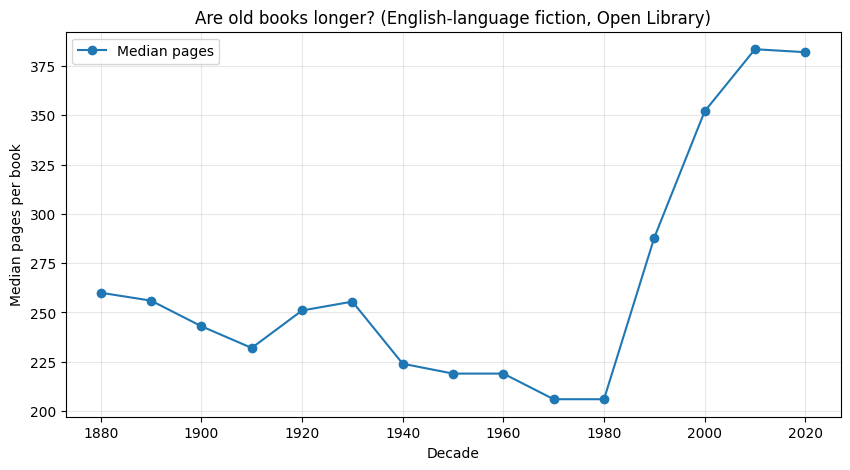

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_decade.index, by_decade["median"], marker="o", label="Median pages")
ax.set_xlabel("Decade")
ax.set_ylabel("Median pages per book")
ax.set_title("Are old books longer? (English-language fiction, Open Library)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 5. What do you see?

Look at the plot. A few things to think about:

- Was your hypothesis right?
- Is the trend smooth, or are there bumps? Why might that be?
- Look at the `count` column above — are some decades represented by way more books than others? Does that affect how much you trust the median?
- Open Library's data comes mostly from US/UK library catalogues. How might that bias the results?

Write your observations here:

> *What I noticed: ...*

## 6. Stretch challenges

Pick one (or more) and try it. Add new cells below.

1. **Distributions, not just medians.** A median hides the shape of the data. Draw a [box plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html) of page counts per decade. Are old books *more variable* in length, or less?
2. **Genre breakdown.** Instead of all fiction, fetch a specific subject like `science_fiction`, `mystery`, or `romance`. (Change the query in `fetch_decade`.) Did sci-fi books get longer faster than romance?
3. **Most prolific authors per decade.** Use `clean.explode("author_name")` and `value_counts()` to find the top 5 authors per decade. Any surprises?
4. **Language comparison.** Re-fetch with `language:fre` (French) and compare to English. Did French novels follow the same trend?
5. **The Harry Potter effect.** Some people claim books got longer in the late 1990s because of Harry Potter and big fantasy series. Can you find evidence for or against this in the data?